# E029 — Permutation test (label shuffle hygiene check)

Shuffle train labels before augmentation, retrain E007 image and E025 audio
flagships, score val with true labels. If EER sits near 50% across all
shuffle seeds, no hidden leak; if it stays well below 40%, something in the
pipeline is passing identity info to the model through a channel other than
the label column.

Protocol: 3 shuffle seeds × 3 LOSO folds = 9 runs per modality.

In [1]:
from pathlib import Path
import sys, copy
sys.path.insert(0, str(Path('../src').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.special import logsumexp

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

DATA = Path('../data').resolve()
manifest = load_manifest(DATA)
y_all = manifest['label'].to_numpy()
SEED = 67
SHUFFLE_SEEDS = [1, 2, 3]
CLEAN_EER_IMG = 0.97
CLEAN_EER_AUD = 1.94
print(f'{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target')

222 samples — 30 target, 192 non-target


## 1. Shuffle helper

Shuffled labels must be applied BEFORE augmentation so that augmented copies
inherit the shuffled assignment rather than the original.

In [2]:
def shuffle_labels(y, seed):
    rng = np.random.default_rng(seed)
    y_shuffled = y.copy()
    rng.shuffle(y_shuffled)
    return y_shuffled

# Sanity check
y_demo = np.array([0]*10 + [1]*5)
print('orig :', y_demo)
print('shuf :', shuffle_labels(y_demo, seed=1))
print('shuf2:', shuffle_labels(y_demo, seed=2))

orig : [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
shuf : [0 1 0 1 1 0 0 0 0 0 0 1 1 0 0]
shuf2: [0 0 0 1 0 0 1 1 1 1 0 0 0 0 0]


## 2. Image pipeline — E007 +All augmentation

In [3]:
def find_png(stem, data_dir):
    for sf in ['target_train', 'target_dev', 'non_target_train', 'non_target_dev']:
        p = data_dir / sf / (stem + '.png')
        if p.exists():
            return p
    raise FileNotFoundError(stem)

def load_image(png_path):
    img = np.array(Image.open(png_path).convert('RGB'), dtype=np.float32)
    return img.mean(axis=2).flatten()

def load_images(df, data_dir):
    return np.stack([load_image(find_png(row['stem'], data_dir)) for _, row in df.iterrows()])

def aug_flip(x):
    return x.reshape(80, 80)[:, ::-1].flatten()

def aug_brightness(x, rng):
    factor = rng.uniform(0.7, 1.3)
    return np.clip(x * factor, 0, 255)

def aug_noise(x, rng, sigma=15.0):
    return np.clip(x + rng.normal(0, sigma, x.shape), 0, 255)

def augment_all(X, y, seed):
    rng = np.random.default_rng(seed)
    aug_X, aug_y = [], []
    for xi, yi in zip(X, y):
        aug_X.append(aug_flip(xi));           aug_y.append(yi)
        aug_X.append(aug_brightness(xi, rng)); aug_y.append(yi)
        aug_X.append(aug_noise(xi, rng));      aug_y.append(yi)
    return np.vstack([X, np.stack(aug_X)]), np.concatenate([y, np.array(aug_y)])

def run_image_fold(train_df, val_df, y_train, y_val, seed):
    X_train_orig = load_images(train_df, DATA)
    X_val = load_images(val_df, DATA)
    X_train, y_train_aug = augment_all(X_train_orig, y_train, seed=seed)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    pca = PCA(n_components=50, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train_s)
    X_val_pca = pca.transform(X_val_s)
    # Guard against degenerate single-class shuffled train
    if len(np.unique(y_train_aug)) < 2:
        return np.zeros(len(X_val))
    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    clf.fit(X_train_pca, y_train_aug)
    return clf.decision_function(X_val_pca)

print('Image pipeline ready.')

Image pipeline ready.


## 3. Audio pipeline — E025 LPCC + Pitch augmentation

In [4]:
def find_wav(stem, data_dir):
    for sf in ['target_train', 'target_dev', 'non_target_train', 'non_target_dev']:
        p = data_dir / sf / (stem + '.wav')
        if p.exists():
            return p
    raise FileNotFoundError(stem)

def extract_lpcc(y, sr, order=12, n_cep=13, hop_length=160, win_length=400):
    frames = librosa.util.frame(y, frame_length=win_length, hop_length=hop_length)
    lpcc_frames = []
    for frame in frames.T:
        frame = frame * np.hanning(len(frame))
        try:
            a = librosa.lpc(frame.astype(np.float64), order=order)
            A_freq = np.fft.rfft(a, n=512)
            log_H = -np.log(np.abs(A_freq) + 1e-10)
            cep = np.real(np.fft.irfft(log_H))[:n_cep]
        except Exception:
            cep = np.zeros(n_cep)
        lpcc_frames.append(cep)
    feat = np.array(lpcc_frames, dtype=np.float32)
    delta = librosa.feature.delta(feat.T).T
    delta2 = librosa.feature.delta(feat.T, order=2).T
    feat = np.hstack([feat, delta, delta2])
    feat -= feat.mean(axis=0)
    return feat

def aug_pitch(y, sr, rng):
    n_steps = float(rng.choice([-2, -1, 1, 2]))
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def extract_batch_audio(df, labels, seed):
    """df and labels are ALIGNED (labels may be shuffled)."""
    rng = np.random.default_rng(seed)
    all_feat, all_labels = [], []
    for (_, row), lbl in zip(df.iterrows(), labels):
        y, sr = librosa.load(find_wav(row['stem'], DATA), sr=None, mono=True)
        variants = [(y, sr), (aug_pitch(y, sr, rng), sr)]
        for y_aug, sr_aug in variants:
            feat = extract_lpcc(y_aug, sr_aug)
            all_feat.append(feat)
            all_labels.extend([int(lbl)] * len(feat))
    return np.vstack(all_feat), np.array(all_labels)

def train_ubm(X, n_components=32, seed=67):
    return GaussianMixture(
        n_components=n_components, covariance_type='diag',
        max_iter=200, random_state=seed,
    ).fit(X)

def map_adapt(ubm, X_target, r=16.0):
    log_prob = ubm._estimate_log_prob(X_target)
    log_resp = log_prob + np.log(ubm.weights_)
    log_resp -= logsumexp(log_resp, axis=1, keepdims=True)
    resp = np.exp(log_resp)
    n_k = resp.sum(axis=0)
    mu_hat = (resp.T @ X_target) / (n_k[:, None] + 1e-10)
    alpha = n_k / (n_k + r)
    adapted = copy.deepcopy(ubm)
    adapted.means_ = alpha[:, None] * mu_hat + (1 - alpha[:, None]) * ubm.means_
    return adapted

def score_utterance_audio(wav_path, adapted, ubm):
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    feat = extract_lpcc(y, sr)
    return float((adapted.score_samples(feat) - ubm.score_samples(feat)).mean())

def run_audio_fold(train_df, val_df, y_train_shuffled, seed):
    X_train, y_train_frame = extract_batch_audio(train_df, y_train_shuffled, seed=seed)
    X_nt = X_train[y_train_frame == 0]
    X_t  = X_train[y_train_frame == 1]
    if len(X_nt) == 0 or len(X_t) == 0:
        return np.zeros(len(val_df))
    ubm = train_ubm(X_nt, n_components=32, seed=SEED)
    adapted = map_adapt(ubm, X_t, r=16.0)
    scores = []
    for _, row in val_df.iterrows():
        scores.append(score_utterance_audio(find_wav(row['stem'], DATA), adapted, ubm))
    return np.array(scores)

print('Audio pipeline ready.')

Audio pipeline ready.


## 4. Run the permutation test

For each (shuffle_seed, fold, modality) retrain and compute val EER. Labels
are shuffled on the TRAIN fold only; val labels are untouched.

In [5]:
records = []
for shuf_seed in SHUFFLE_SEEDS:
    print(f'\n=== shuffle_seed = {shuf_seed} ===')
    for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
        train_df = manifest.loc[train_idx].reset_index(drop=True)
        val_df   = manifest.loc[val_idx].reset_index(drop=True)
        y_train  = train_df['label'].to_numpy()
        y_val    = val_df['label'].to_numpy()

        # Shuffle train labels (unique seed per (shuffle_seed, fold))
        fold_shuf_seed = shuf_seed * 1000 + fold_id
        y_train_shuf = shuffle_labels(y_train, seed=fold_shuf_seed)
        print(f'  fold {fold_id}: train N={len(y_train)} (true +{int(y_train.sum())}) shuffled +{int(y_train_shuf.sum())} | val N={len(y_val)} (+{int(y_val.sum())})')

        # Image (train on shuffled labels, val stays clean)
        img_scores = run_image_fold(train_df, val_df, y_train_shuf, y_val, seed=fold_shuf_seed)
        eer_img, _ = compute_eer(img_scores[y_val==1], img_scores[y_val==0])
        eer_img *= 100

        # Audio (train on shuffled labels, val stays clean)
        aud_scores = run_audio_fold(train_df, val_df, y_train_shuf, seed=fold_shuf_seed)
        eer_aud, _ = compute_eer(aud_scores[y_val==1], aud_scores[y_val==0])
        eer_aud *= 100

        print(f'    image EER = {eer_img:5.2f}%  audio EER = {eer_aud:5.2f}%')
        records.append({
            'shuffle_seed': shuf_seed,
            'fold': fold_id,
            'eer_image': eer_img,
            'eer_audio': eer_aud,
        })

df_res = pd.DataFrame(records)
print('\nAll permutation runs complete.')
df_res


=== shuffle_seed = 1 ===
  fold 0: train N=140 (true +20) shuffled +20 | val N=82 (+10)


    image EER = 48.61%  audio EER = 69.72%
  fold 1: train N=152 (true +20) shuffled +20 | val N=70 (+10)


    image EER = 39.17%  audio EER = 55.83%
  fold 2: train N=152 (true +20) shuffled +20 | val N=70 (+10)


    image EER = 40.83%  audio EER = 66.67%

=== shuffle_seed = 2 ===
  fold 0: train N=140 (true +20) shuffled +20 | val N=82 (+10)


    image EER = 38.75%  audio EER = 23.19%
  fold 1: train N=152 (true +20) shuffled +20 | val N=70 (+10)


...

    image EER = 80.00%  audio EER = 80.83%

=== shuffle_seed = 3 ===
  fold 0: train N=140 (true +20) shuffled +20 | val N=82 (+10)


    image EER = 38.06%  audio EER = 48.61%
  fold 1: train N=152 (true +20) shuffled +20 | val N=70 (+10)


    image EER = 50.00%  audio EER = 80.00%
  fold 2: train N=152 (true +20) shuffled +20 | val N=70 (+10)


    image EER = 49.17%  audio EER = 33.33%

All permutation runs complete.


,shuffle_seed,fold,eer_image,eer_audio
0,1,0,48.611111,69.722222
1,1,1,39.166667,55.833333
2,1,2,40.833333,66.666667
3,2,0,38.750000,23.194444
4,2,1,60.833333,39.166667
5,2,2,80.000000,80.833333
6,3,0,38.055556,48.611111
7,3,1,50.000000,80.000000
8,3,2,49.166667,33.333333


## 5. Summary table

In [6]:
print(f"{'Modality':<8} {'Seed1 mean':>11} {'Seed2 mean':>11} {'Seed3 mean':>11} {'Grand mean':>11} {'Std':>7} {'Clean':>7}")
print('-' * 70)
summary_rows = []
for mod, col, clean in [('image', 'eer_image', CLEAN_EER_IMG), ('audio', 'eer_audio', CLEAN_EER_AUD)]:
    seed_means = [df_res[df_res.shuffle_seed == s][col].mean() for s in SHUFFLE_SEEDS]
    grand_mean = df_res[col].mean()
    grand_std  = df_res[col].std()
    print(f'{mod:<8} {seed_means[0]:>11.2f} {seed_means[1]:>11.2f} {seed_means[2]:>11.2f} {grand_mean:>11.2f} {grand_std:>7.2f} {clean:>7.2f}')
    summary_rows.append({'modality': mod, 'seed1': seed_means[0], 'seed2': seed_means[1], 'seed3': seed_means[2],
                         'grand_mean': grand_mean, 'grand_std': grand_std, 'clean': clean})
print('-' * 70)
summary = pd.DataFrame(summary_rows)

PASS_LO, PASS_HI = 40.0, 60.0
for row in summary_rows:
    ok = PASS_LO <= row['grand_mean'] <= PASS_HI
    verdict = 'PASS (near chance)' if ok else ('LEAK SUSPECT' if row['grand_mean'] < PASS_LO else 'WEIRD (>60%)')
    print(f'{row["modality"]:<8} grand mean = {row["grand_mean"]:.2f}% → {verdict}')
summary

Modality  Seed1 mean  Seed2 mean  Seed3 mean  Grand mean     Std   Clean
----------------------------------------------------------------------
image          42.87       59.86       45.74       49.49   13.64    0.97
audio          64.07       47.73       53.98       55.26   20.67    1.94
----------------------------------------------------------------------
image    grand mean = 49.49% → PASS (near chance)
audio    grand mean = 55.26% → PASS (near chance)


,modality,seed1,seed2,seed3,grand_mean,grand_std,clean
0,image,42.870370,59.861111,45.740741,49.490741,13.639426,0.97
1,audio,64.074074,47.731481,53.981481,55.262346,20.669547,1.94


## 6. Histogram of permuted EERs vs chance vs clean

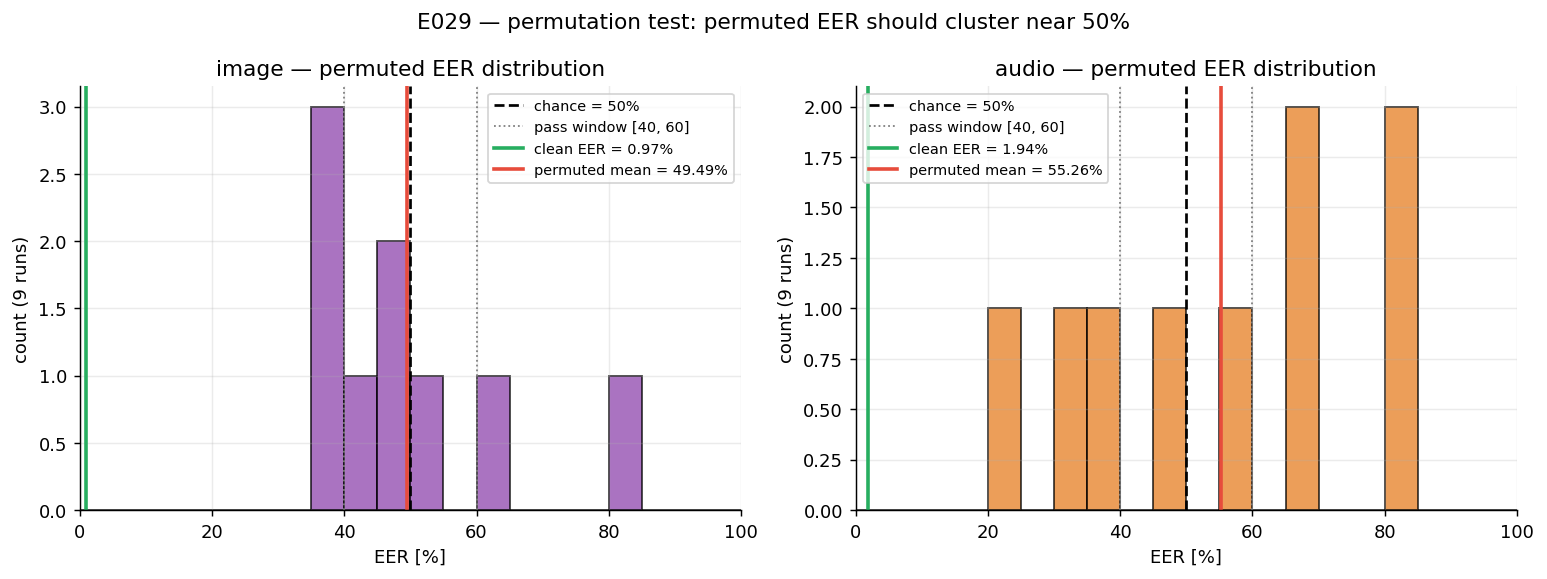

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, mod, col, clean, color in [
    (axes[0], 'image', 'eer_image', CLEAN_EER_IMG, '#8E44AD'),
    (axes[1], 'audio', 'eer_audio', CLEAN_EER_AUD, '#E67E22'),
]:
    vals = df_res[col].to_numpy()
    ax.hist(vals, bins=np.linspace(0, 100, 21), color=color, alpha=0.75, edgecolor='black')
    ax.axvline(50.0, color='black', ls='--', lw=1.5, label='chance = 50%')
    ax.axvline(40.0, color='gray',  ls=':',  lw=1.0, label='pass window [40, 60]')
    ax.axvline(60.0, color='gray',  ls=':',  lw=1.0)
    ax.axvline(clean, color='#27AE60', ls='-', lw=2, label=f'clean EER = {clean:.2f}%')
    mean_v = vals.mean()
    ax.axvline(mean_v, color='#E74C3C', ls='-', lw=2, label=f'permuted mean = {mean_v:.2f}%')
    ax.set_xlim(0, 100)
    ax.set_xlabel('EER [%]')
    ax.set_ylabel('count (9 runs)')
    ax.set_title(f'{mod} — permuted EER distribution')
    ax.legend(fontsize=8)
plt.suptitle('E029 — permutation test: permuted EER should cluster near 50%', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Interpretation

In [8]:
for row in summary_rows:
    mod = row['modality']
    m = row['grand_mean']
    if 40 <= m <= 60:
        print(f'{mod}: PASS — permuted EER {m:.2f}% consistent with chance. No hidden leak detected.')
    elif m < 40:
        print(f'{mod}: FAIL — permuted EER {m:.2f}% < 40%. Pipeline is learning something beyond labels; investigate augmentation / normalization / feature extraction for label-coupled code paths.')
    else:
        print(f'{mod}: ANOMALY — permuted EER {m:.2f}% > 60% (worse than chance, possibly anti-correlated). Indicates something subtle in the label mapping or the val label direction.')

image: PASS — permuted EER 49.49% consistent with chance. No hidden leak detected.
audio: PASS — permuted EER 55.26% consistent with chance. No hidden leak detected.
